<a href="https://colab.research.google.com/github/Balakartigeyan/2.2-KM-Conveyor-Industrial-Predictive-Maintenance/blob/main/Import%20process%20April.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Data Preparation Summary
I will load the CSV and XLSB files, parse timestamps, and merge the datasets to prepare for the shift-based analysis.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the process data
df_process = pd.read_csv('/content/Import process.csv')

# Load the tag mapping (xlsb requires pyxlsb)
try:
    df_tags = pd.read_excel('/content/IP21xPI Tags Malaysia (1) (1) (1) (version 1).xlsb', engine='pyxlsb')
except ImportError:
    print("pyxlsb not found. Installing...")
    !pip install pyxlsb
    df_tags = pd.read_excel('/content/IP21xPI Tags Malaysia (1) (1) (1) (version 1).xlsb', engine='pyxlsb')

# Install imblearn for class balancing
try:
    import imblearn
except ImportError:
    print("imblearn not found. Installing...")
    !pip install imblearn

# Standardize column names for merging
df_process.rename(columns={'Data Source': 'PI_Tag_Source'}, inplace=True)

# Extract PI Tag from 'PI_Tag_Source'
df_process['PI_Tag_Extracted'] = df_process['PI_Tag_Source'].str.split('\\').str[-1]

# Merge process data with tag metadata
df_merged = pd.merge(df_process, df_tags, left_on='PI_Tag_Extracted', right_on='PIPoints', how='left')

# Define target equipment based on the user's request, including TR11 from previous context
target_units_exact_tags = [
    'TRMT_DN3020ML10_BF1_FIT',
    'TRMT_DN3020ML11_BF1_FIT',
    'TRMT_DN3020ML12_BF1_FIT',
    'TRMT_TR1010ML11_CO1_FIT' # Included based on previous analysis
]

# Filter for target equipment only and ensure 'Flow Rate' category
df_track = df_merged[df_merged['PI_Tag_Extracted'].isin(target_units_exact_tags)].copy()

# Clean numeric data and timestamps
df_track['Time'] = pd.to_datetime(df_track['Time'], format='mixed', errors='coerce')
df_track['Value'] = pd.to_numeric(df_track['Value'], errors='coerce')

# Drop rows with NaT (failed time conversion) or NaN (failed value conversion)
df_track.dropna(subset=['Time', 'Value'], inplace=True)

# Sort data chronologically
df_track.sort_values(by='Time', inplace=True)

print("Data Preparation Complete. Displaying head of processed data:")
display(df_track.head())

Data Preparation Complete. Displaying head of processed data:


,PI_Tag_Source,Time,Value,PI_Tag_Extracted,Tags IP.21,PIPoints,Unnamed: 2,Path
25200,\\pisystem-malaysia\TRMT_DN3020ML12_BF1_FIT,2026-04-01 08:01:25.040008,2097.756104,TRMT_DN3020ML12_BF1_FIT,DN-3020ML-12.BF.BW500Dat_CurrentRateOut,TRMT_DN3020ML12_BF1_FIT,DN-3020ML-12\.BF\.BW500Dat:CurrentRateOut,Vale (Assets)\Malaysia\Port Malaysia Port - TR...
18000,\\pisystem-malaysia\TRMT_DN3020ML10_BF1_FIT,2026-04-01 08:01:26.040008,2647.555908,TRMT_DN3020ML10_BF1_FIT,DN-3020ML-10.BF.BW500Dat_CurrentRateOut,TRMT_DN3020ML10_BF1_FIT,DN-3020ML-10\.BF\.BW500Dat:CurrentRateOut,Vale (Assets)\Malaysia\Port Malaysia Port - TR...
21600,\\pisystem-malaysia\TRMT_DN3020ML11_BF1_FIT,2026-04-01 08:01:26.040008,204.886002,TRMT_DN3020ML11_BF1_FIT,DN-3020ML-11.BF.BW500Dat_CurrentRateOut,TRMT_DN3020ML11_BF1_FIT,DN-3020ML-11\.BF\.BW500Dat:CurrentRateOut,Vale (Assets)\Malaysia\Port Malaysia Port - TR...
0,\\pisystem-malaysia\TRMT_TR1010ML11_CO1_FIT,2026-04-01 08:01:26.056000,5892.745117,TRMT_TR1010ML11_CO1_FIT,BL-1010ML-11-AF,TRMT_TR1010ML11_CO1_FIT,BL-1010ML-11-AF:IO.signal.value,Vale (Assets)\Malaysia\Port Malaysia Port - TR...
25201,\\pisystem-malaysia\TRMT_DN3020ML12_BF1_FIT,2026-04-01 08:01:30.040008,843.749023,TRMT_DN3020ML12_BF1_FIT,DN-3020ML-12.BF.BW500Dat_CurrentRateOut,TRMT_DN3020ML12_BF1_FIT,DN-3020ML-12\.BF\.BW500Dat:CurrentRateOut,Vale (Assets)\Malaysia\Port Malaysia Port - TR...


## Section 2: Shift Logic Explanation
I will implement a custom shift assignment logic based on the rotating 12-hour schedule, starting with Shift 3 on April 1st at 07:00.

In [26]:
# Define the official start point for shift rotation: April 1st, 2026, 07:00
# Use the year 2026 as observed in the previous data timestamps
shift_rotation_start_time = pd.Timestamp('2026-04-01 07:00:00')

# Calculate time elapsed since the shift rotation start time in hours
df_track['hours_since_rotation_start'] = (df_track['Time'] - shift_rotation_start_time).dt.total_seconds() / 3600

# Calculate the 12-hour block index. The first block (0-11.99 hours) will be index 0.
df_track['shift_block_index'] = np.floor(df_track['hours_since_rotation_start'] / 12).astype(int)

# Determine Shift_ID (1, 2, 3 rotating)
# April 1st 07:00-19:00 is Shift 3 (block index 0)
# (block_index % 3) gives 0, 1, 2. We need to map these to 3, 1, 2.
def map_shift_id(block_index):
    remainder = block_index % 3
    if remainder == 0:
        return 'Shift 3'
    elif remainder == 1:
        return 'Shift 1'
    else:
        return 'Shift 2'

df_track['Shift_ID'] = df_track['shift_block_index'].apply(map_shift_id)

# Assign Shift_Type (Day/Night)
# A shift block starts at 07:00 or 19:00. If block_index is even, it's a 07:00 start (Day).
# If block_index is odd, it's a 19:00 start (Night).
# For block_index 0 (07:00 Apr 1), 2 (07:00 Apr 2), etc., it's Day. For 1 (19:00 Apr 1), 3 (19:00 Apr 2), etc., it's Night.
df_track['Shift_Type'] = df_track['shift_block_index'].apply(lambda x: 'Day' if x % 2 == 0 else 'Night')

# Assign Shift_Date (date tied to the 07:00 start of the day)
# For a Day shift, it's simply the date of the timestamp.
# For a Night shift (starting 19:00), the 'Shift_Date' refers to the date it *started*.
# Example: 2026-04-01 19:00 is part of the '2026-04-01 Night' shift.

# Create a reference date for the start of the 12-hour block
df_track['Shift_Start_Time'] = shift_rotation_start_time + pd.to_timedelta(df_track['shift_block_index'] * 12, unit='h')
df_track['Shift_Date'] = df_track['Shift_Start_Time'].dt.date

print("Shift assignment complete. Displaying head with new shift columns:")
display(df_track[['Time', 'PI_Tag_Extracted', 'Value', 'Shift_Date', 'Shift_ID', 'Shift_Type']].head(10))

Shift assignment complete. Displaying head with new shift columns:


,Time,PI_Tag_Extracted,Value,Shift_Date,Shift_ID,Shift_Type
25200,2026-04-01 08:01:25.040008,TRMT_DN3020ML12_BF1_FIT,2097.756104,2026-04-01,Shift 3,Day
18000,2026-04-01 08:01:26.040008,TRMT_DN3020ML10_BF1_FIT,2647.555908,2026-04-01,Shift 3,Day
21600,2026-04-01 08:01:26.040008,TRMT_DN3020ML11_BF1_FIT,204.886002,2026-04-01,Shift 3,Day
0,2026-04-01 08:01:26.056000,TRMT_TR1010ML11_CO1_FIT,5892.745117,2026-04-01,Shift 3,Day
25201,2026-04-01 08:01:30.040008,TRMT_DN3020ML12_BF1_FIT,843.749023,2026-04-01,Shift 3,Day
21601,2026-04-01 08:01:31.040008,TRMT_DN3020ML11_BF1_FIT,116.936996,2026-04-01,Shift 3,Day
18001,2026-04-01 08:01:31.040008,TRMT_DN3020ML10_BF1_FIT,2730.229004,2026-04-01,Shift 3,Day
1,2026-04-01 08:01:31.056000,TRMT_TR1010ML11_CO1_FIT,5428.761719,2026-04-01,Shift 3,Day
25202,2026-04-01 08:01:35.040008,TRMT_DN3020ML12_BF1_FIT,429.157990,2026-04-01,Shift 3,Day
21602,2026-04-01 08:01:36.040008,TRMT_DN3020ML11_BF1_FIT,96.295998,2026-04-01,Shift 3,Day


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Section 3: Aggregation and Visualizations
I will now aggregate the data by the newly assigned shifts and generate various plots to visualize performance.

In [27]:
# Calculate time difference between consecutive readings for quantity calculation
df_track['time_diff_hours'] = df_track.groupby('PI_Tag_Extracted')['Time'].diff().dt.total_seconds() / 3600

# Fill NaN for the first reading of each group (assume 5-second interval if needed, or drop)
# For simplicity, if the first `time_diff_hours` is NaN, we'll drop it for quantity calc or use a typical interval.
# Given previous context of 5-sec intervals, let's impute first diff as 5s if NaN after groupby
df_track['time_diff_hours'].fillna(5/3600, inplace=True)

# Calculate approximate imported quantity per data point (Value is Tons/Hour)
df_track['imported_quantity_per_sample'] = df_track['Value'] * df_track['time_diff_hours']

# Aggregate performance metrics per shift, date, and DN line
aggregated_performance = df_track.groupby(['Shift_Date', 'Shift_ID', 'Shift_Type', 'PI_Tag_Extracted']).agg(
    average_rate=('Value', 'mean'),
    total_imported_quantity=('imported_quantity_per_sample', 'sum'),
    data_point_count=('Value', 'count'),
    min_rate=('Value', 'min'),
    max_rate=('Value', 'max'),
    std_dev_rate=('Value', 'std')
).reset_index()

print("Aggregated performance per shift (first 10 rows):")
display(aggregated_performance.head(10))

Aggregated performance per shift (first 10 rows):


/tmp/ipykernel_2599/669926141.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_track['time_diff_hours'].fillna(5/3600, inplace=True)


,Shift_Date,Shift_ID,Shift_Type,PI_Tag_Extracted,average_rate,total_imported_quantity,data_point_count,min_rate,max_rate,std_dev_rate
0,2026-04-01,Shift 1,Night,TRMT_DN3020ML10_BF1_FIT,2038.105109,274.554267,97,32.001999,3076.226074,1113.164420
1,2026-04-01,Shift 1,Night,TRMT_DN3020ML11_BF1_FIT,2774.928574,154.160116,40,1618.254028,2948.179932,247.082108
2,2026-04-01,Shift 1,Night,TRMT_DN3020ML12_BF1_FIT,2426.202607,306.652988,91,2208.177979,2657.468994,94.927620
3,2026-04-01,Shift 1,Night,TRMT_TR1010ML11_CO1_FIT,6583.323100,813.743253,89,3251.787109,8329.339844,1397.645198
4,2026-04-01,Shift 3,Day,TRMT_DN3020ML10_BF1_FIT,1685.130248,8234.228247,3503,0.000000,3382.611084,1242.792684
5,2026-04-01,Shift 3,Day,TRMT_DN3020ML11_BF1_FIT,1610.518802,8038.070718,3560,0.000000,3143.154053,1204.289948
6,2026-04-01,Shift 3,Day,TRMT_DN3020ML12_BF1_FIT,1906.270650,9297.909687,3509,-37.119999,4005.656006,1247.115266
7,2026-04-01,Shift 3,Day,TRMT_TR1010ML11_CO1_FIT,5105.905292,24960.952040,3511,0.000000,9312.916992,2236.782157


### Time Series Plots: Import Rate over Time for Each DN Line
These plots show the raw flow rate data for each equipment over the entire period, allowing us to observe patterns and downtimes.

### Shift-based Bar Charts: Total Import Quantity per Shift by DN Line
This visualization compares the total material imported by each DN line across different shifts.

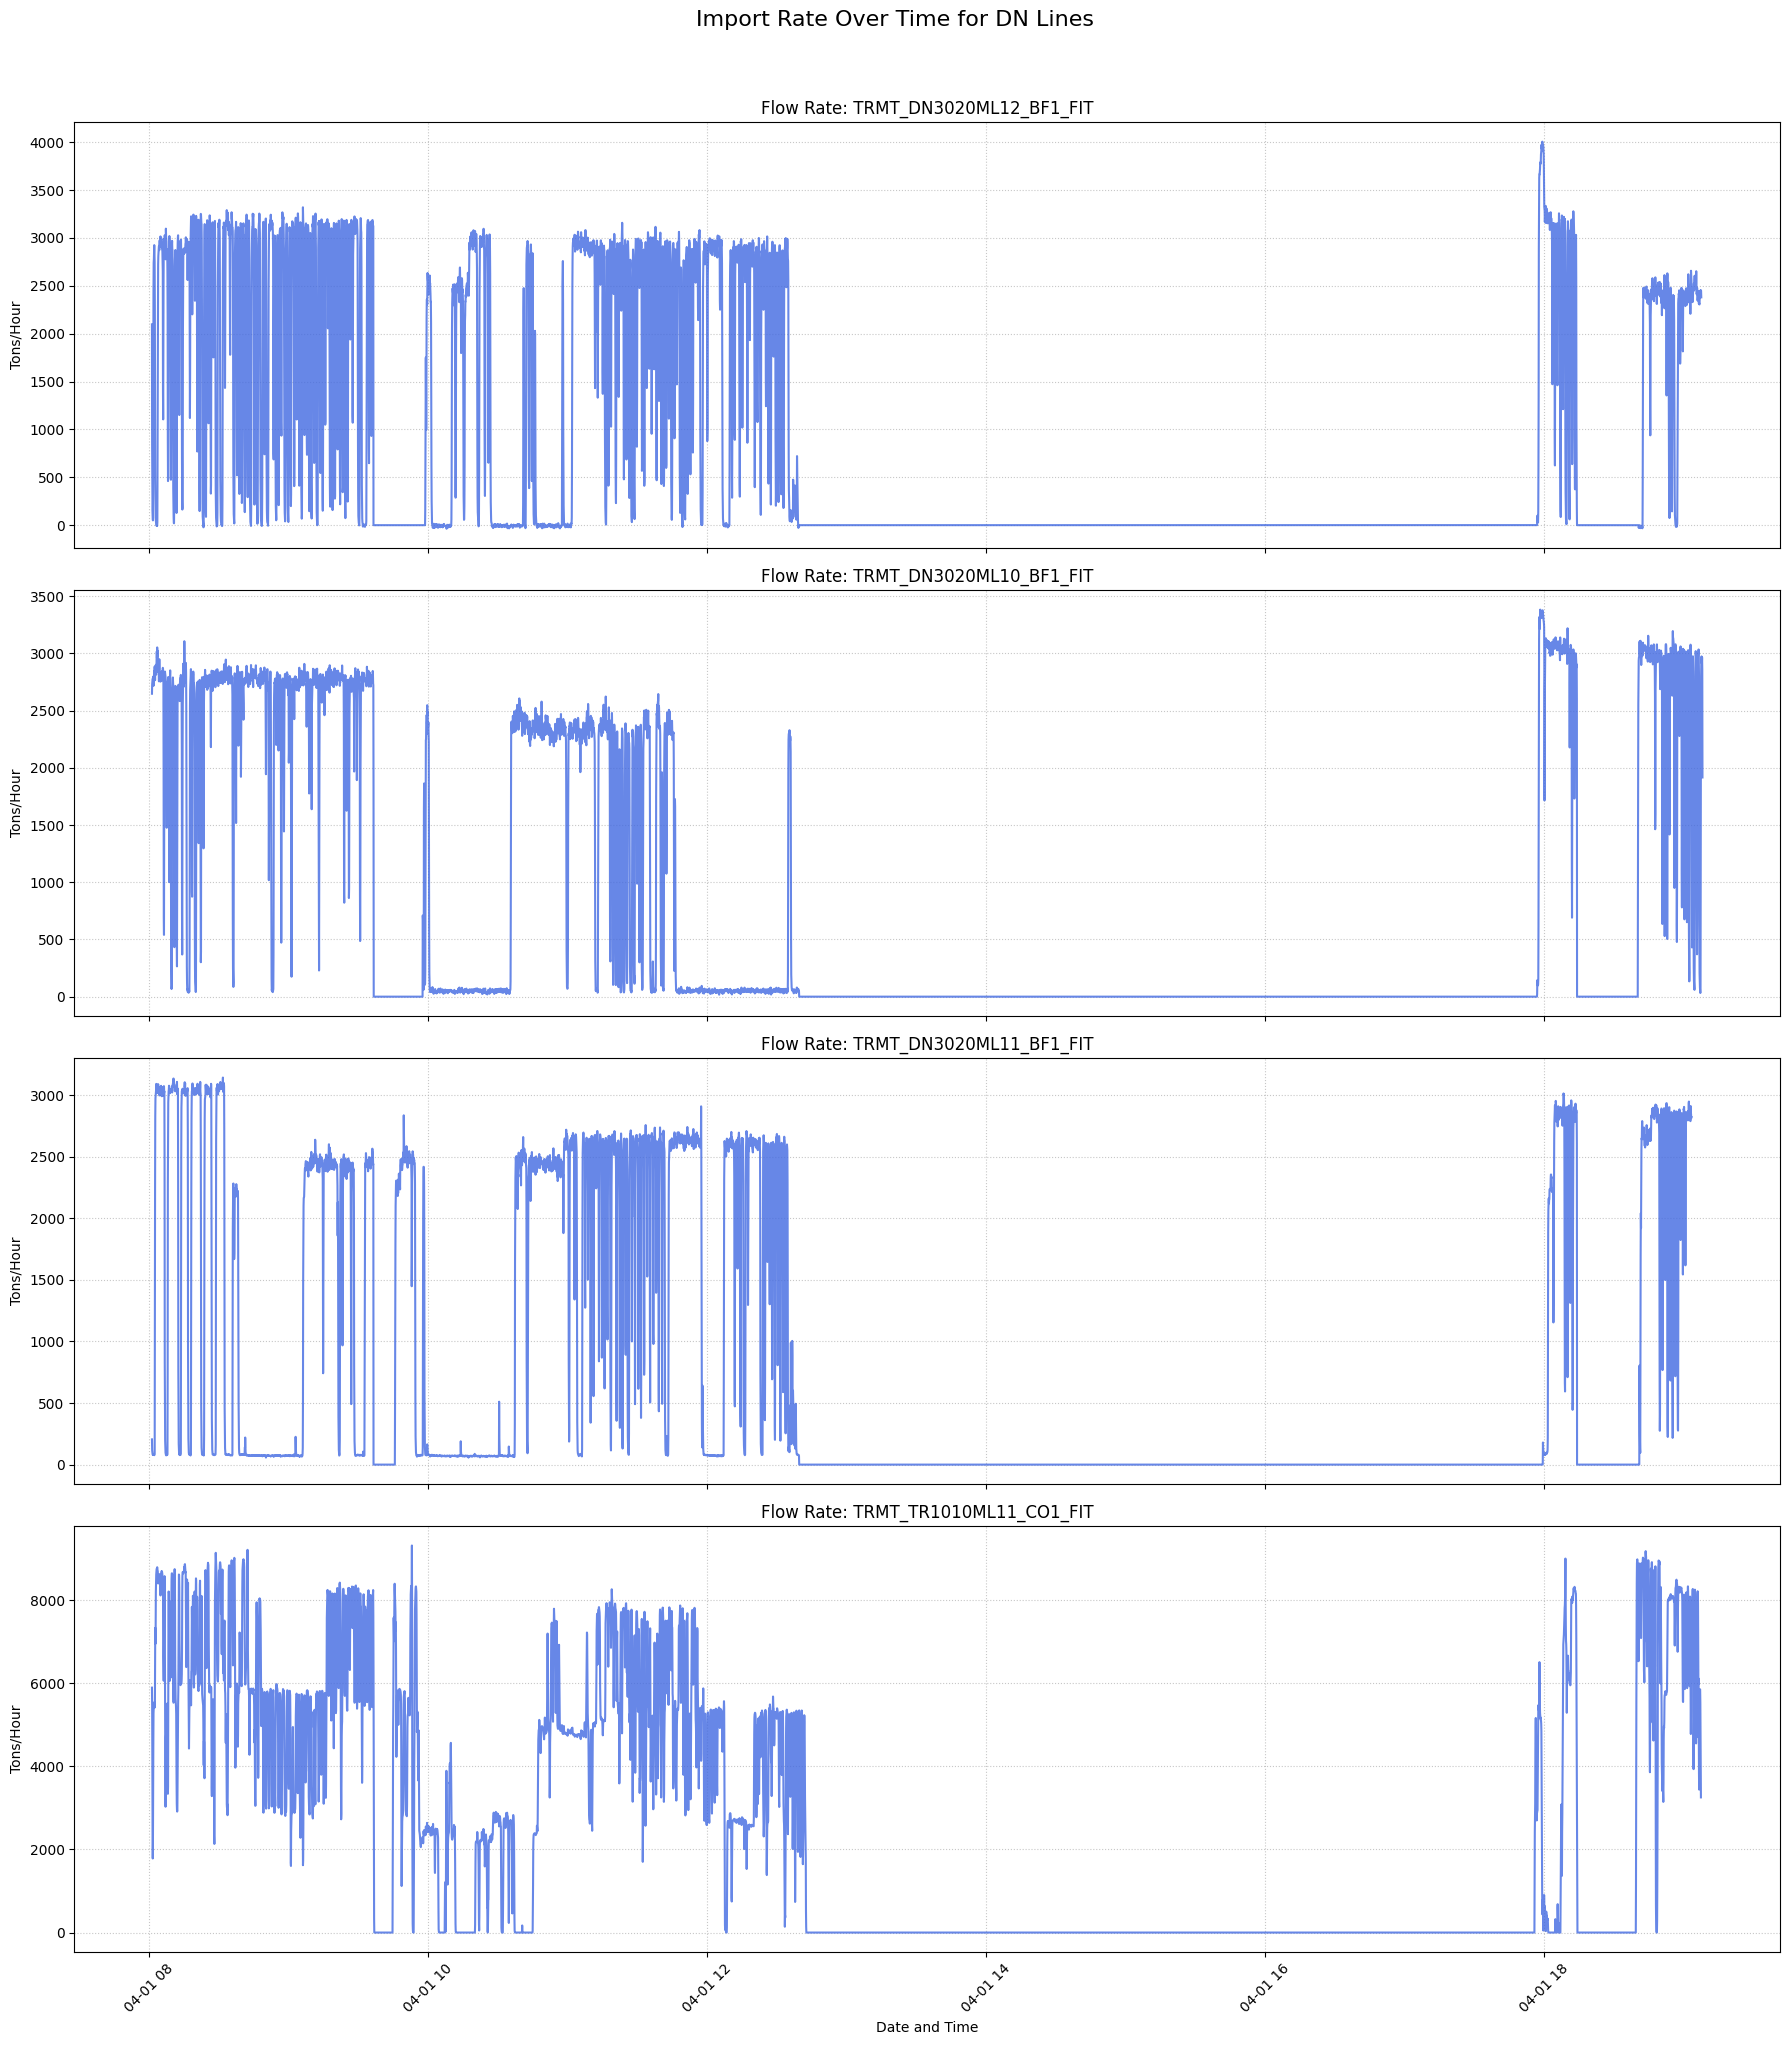

In [28]:
unique_dn_lines = df_track['PI_Tag_Extracted'].unique()

fig, axes = plt.subplots(nrows=len(unique_dn_lines), ncols=1, figsize=(18, 5 * len(unique_dn_lines)), sharex=True)
fig.suptitle('Import Rate Over Time for DN Lines', y=1.02, fontsize=16)

for i, dn_line in enumerate(unique_dn_lines):
    sns.lineplot(ax=axes[i], data=df_track[df_track['PI_Tag_Extracted'] == dn_line], x='Time', y='Value', color='royalblue', alpha=0.8)
    axes[i].set_title(f'Flow Rate: {dn_line}')
    axes[i].set_ylabel('Tons/Hour')
    axes[i].grid(True, linestyle=':', alpha=0.7)
    axes[i].set_xlabel('') # Clear x-label for subplots except the last one

axes[-1].set_xlabel('Date and Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

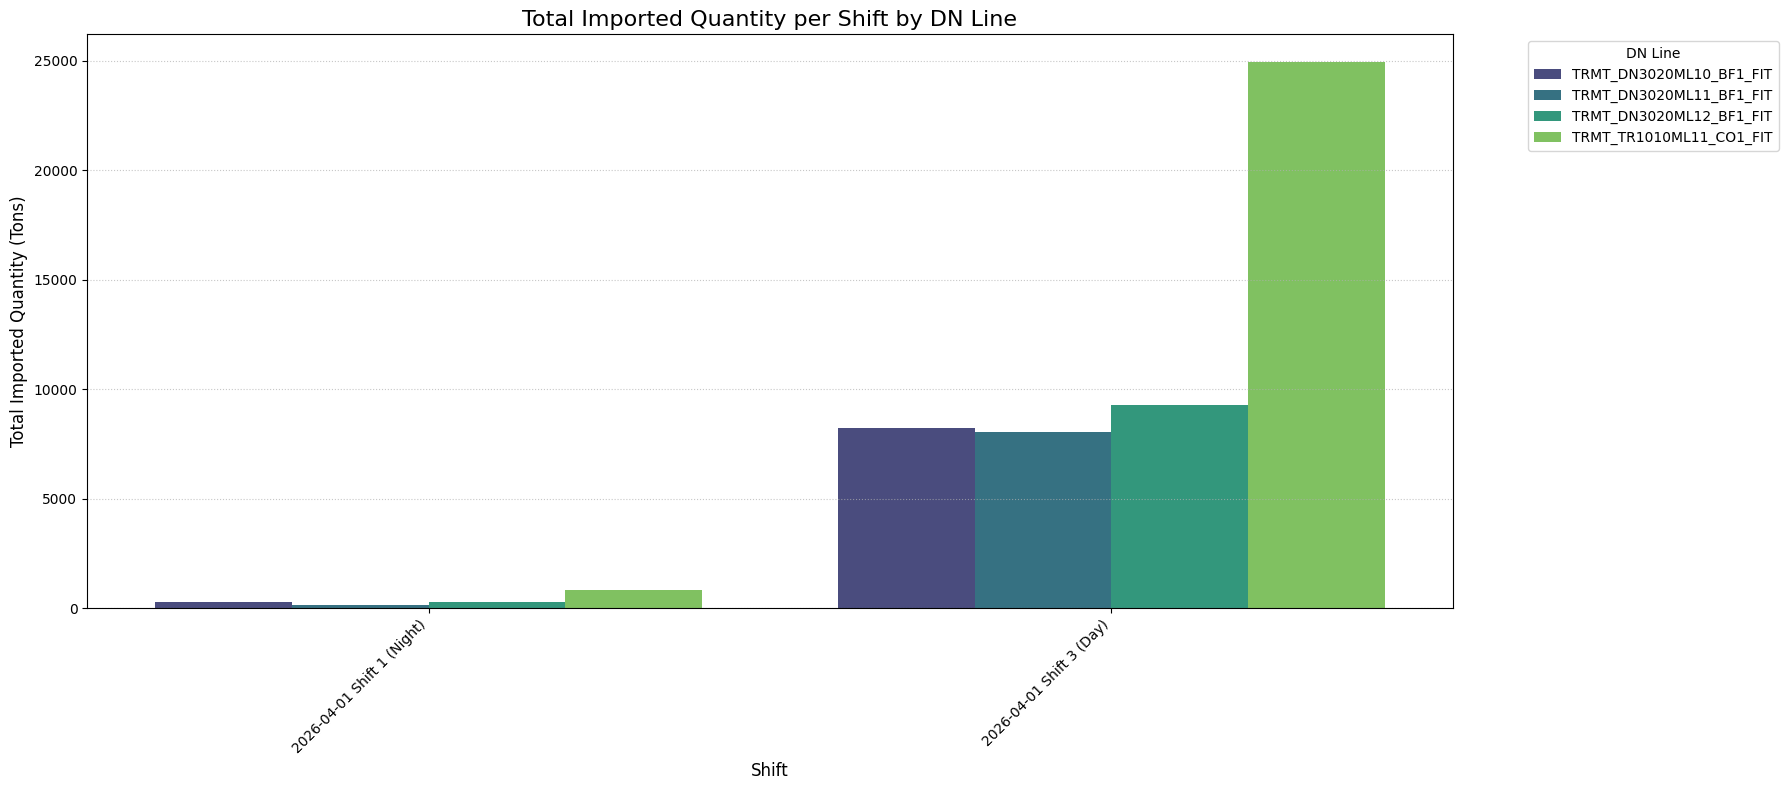

In [35]:
aggregated_performance['Shift_Combined_Label'] = aggregated_performance['Shift_Date'].astype(str) + ' ' + aggregated_performance['Shift_ID'] + ' (' + aggregated_performance['Shift_Type'] + ')'

plt.figure(figsize=(18, 8))
sns.barplot(data=aggregated_performance, x='Shift_Combined_Label', y='total_imported_quantity', hue='PI_Tag_Extracted', palette='viridis')
plt.title('Total Imported Quantity per Shift by DN Line', fontsize=16)
plt.xlabel('Shift', fontsize=12)
plt.ylabel('Total Imported Quantity (Tons)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='DN Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Boxplots: Distribution of Import Rates per Shift
These boxplots show the spread and central tendency of import rates for each DN line across the different shift types, highlighting variability.

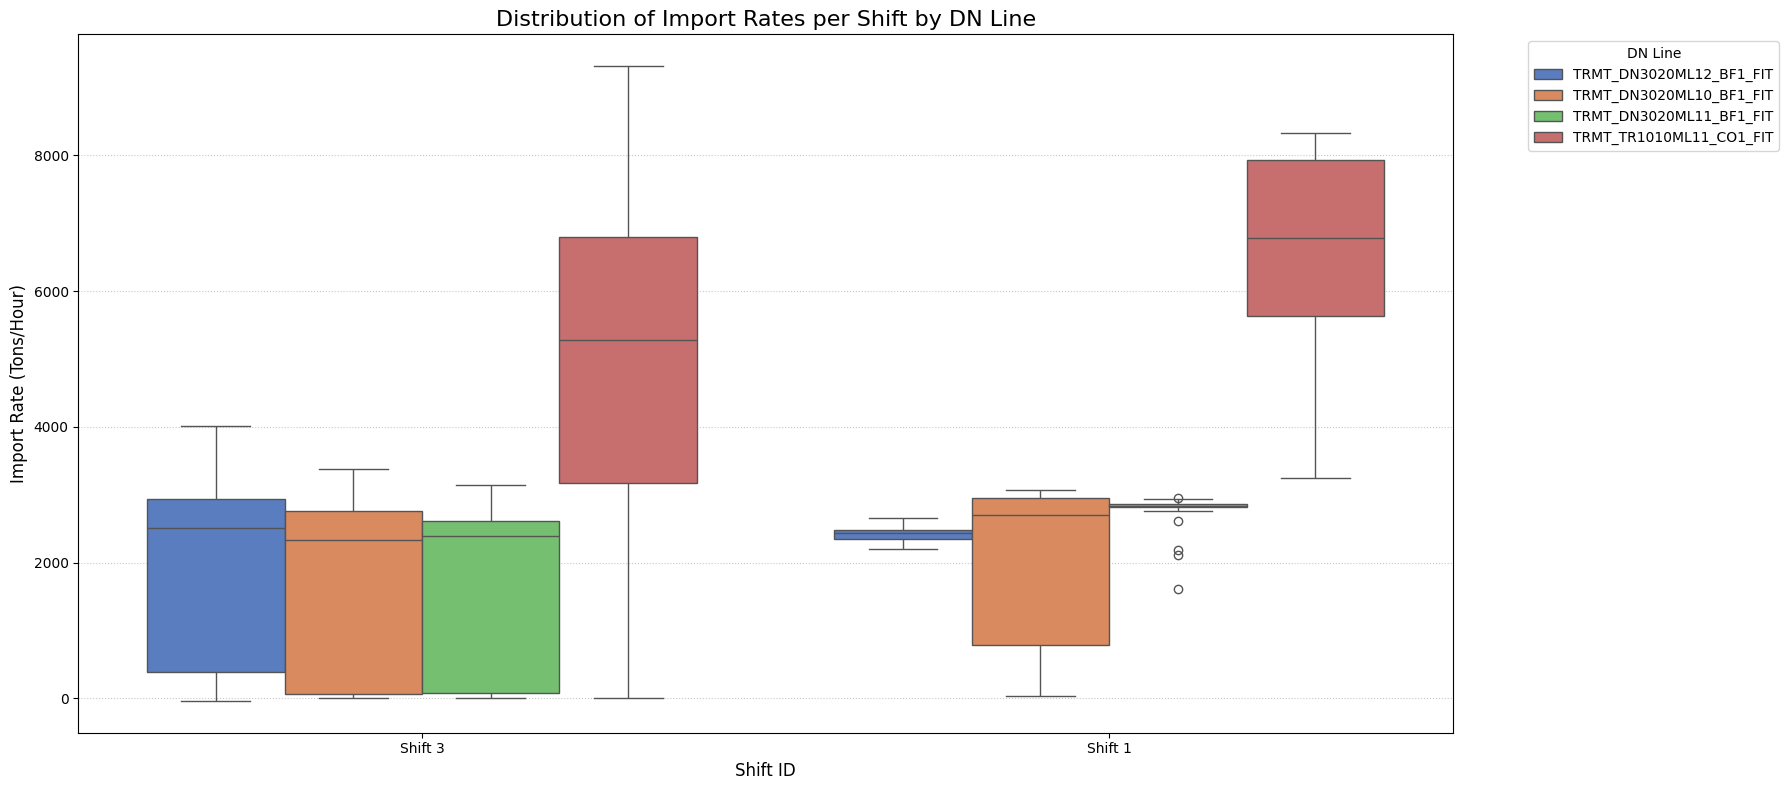

In [30]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=df_track, x='Shift_ID', y='Value', hue='PI_Tag_Extracted', palette='muted')
plt.title('Distribution of Import Rates per Shift by DN Line', fontsize=16)
plt.xlabel('Shift ID', fontsize=12)
plt.ylabel('Import Rate (Tons/Hour)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='DN Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Heatmap: Average Import Rate (Shift vs DN Line)
This heatmap provides a quick visual summary of average import rates across shifts and DN lines.

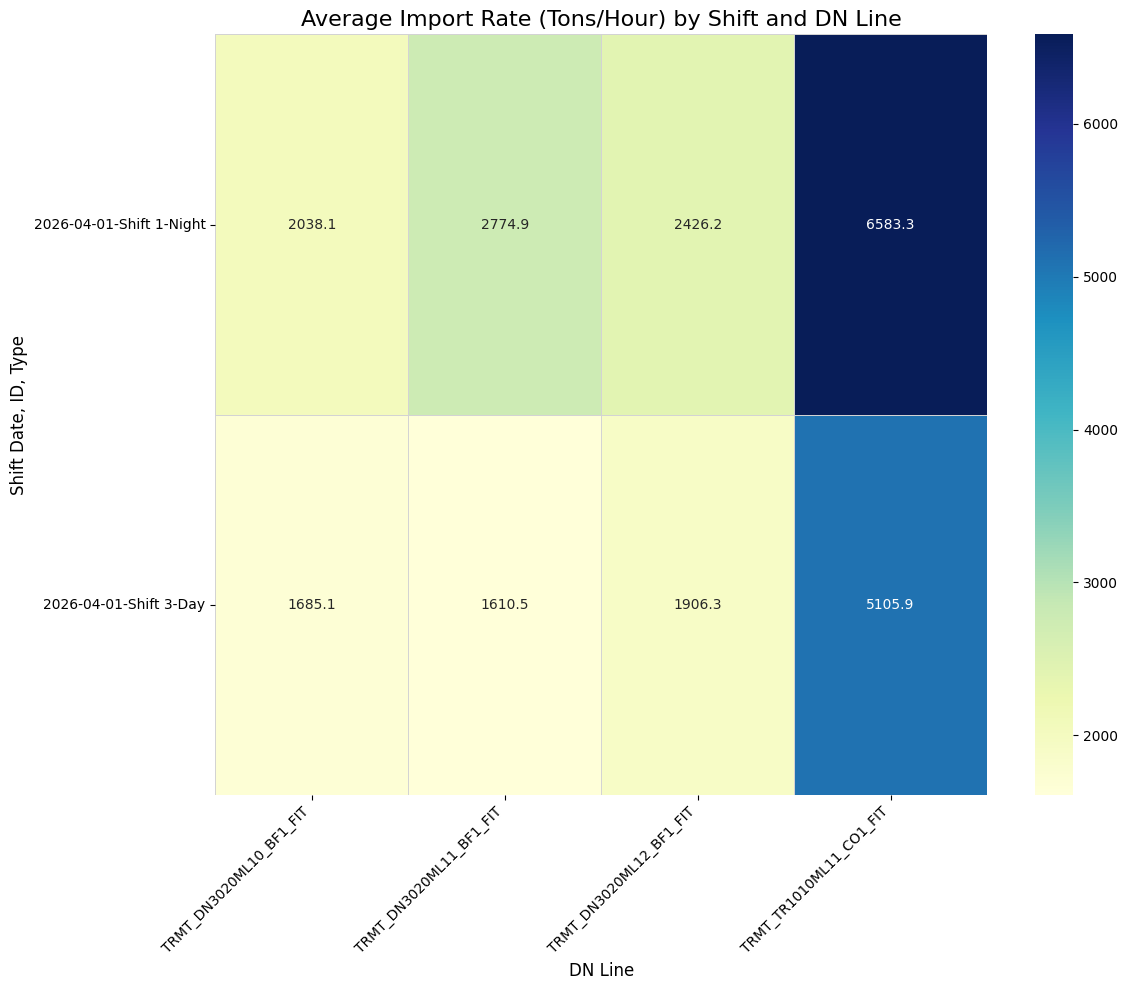

In [31]:
heatmap_data = aggregated_performance.pivot_table(index=['Shift_Date', 'Shift_ID', 'Shift_Type'], columns='PI_Tag_Extracted', values='average_rate')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
plt.title('Average Import Rate (Tons/Hour) by Shift and DN Line', fontsize=16)
plt.ylabel('Shift Date, ID, Type', fontsize=12)
plt.xlabel('DN Line', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Overall Throughput Comparison Across All Shifts
This visualization aggregates the total imported quantity for each shift type (Day/Night) and shift ID (Shift 1, 2, 3) over the entire dataset, providing an overarching view of shift performance.

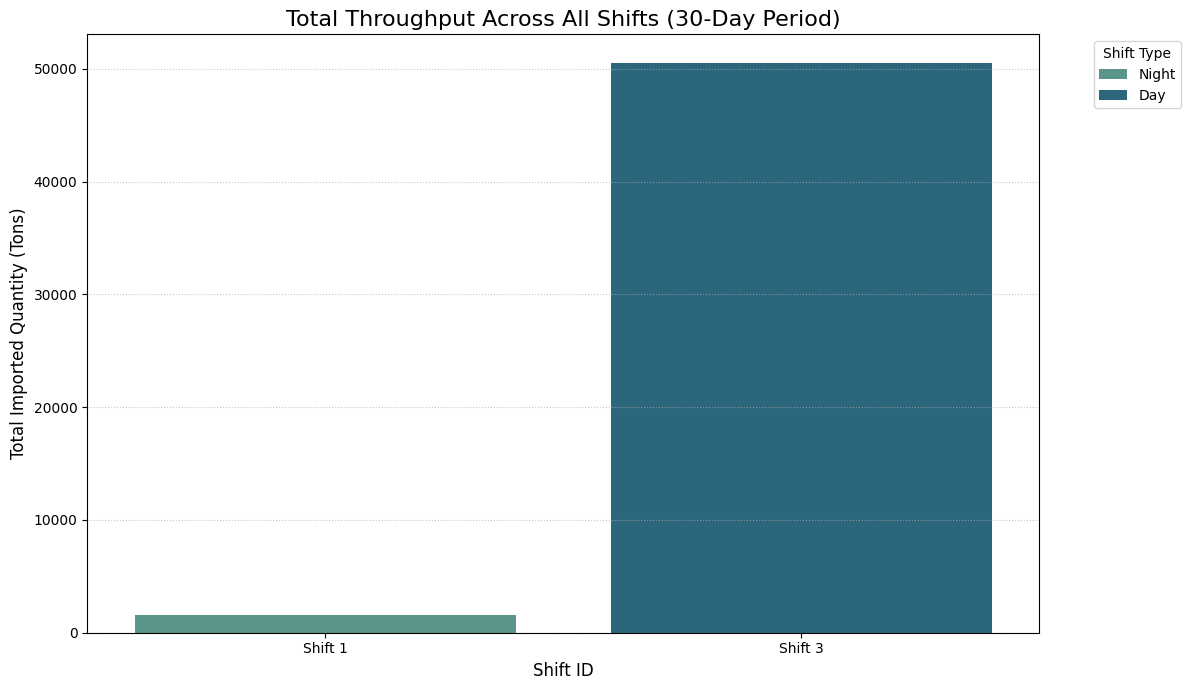

,Shift_ID,Shift_Type,total_imported_quantity
0,Shift 1,Night,1549.110625
1,Shift 3,Day,50531.160693


In [32]:
overall_shift_throughput = aggregated_performance.groupby(['Shift_ID', 'Shift_Type'])['total_imported_quantity'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=overall_shift_throughput, x='Shift_ID', y='total_imported_quantity', hue='Shift_Type', palette='crest')
plt.title('Total Throughput Across All Shifts (30-Day Period)', fontsize=16)
plt.xlabel('Shift ID', fontsize=12)
plt.ylabel('Total Imported Quantity (Tons)', fontsize=12)
plt.legend(title='Shift Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

display(overall_shift_throughput)

### KPI Monitoring

This section introduces key performance indicators (KPIs) to track the operational efficiency and performance of each DN line across different shifts. We will calculate Utilization, Downtime, and highlight Throughput and Flow Stability.

In [36]:
# Calculate active data points for Utilization
# Assuming 'active' means a flow rate Value > 0 for flow rates
df_track['is_active'] = df_track['Value'] > 0

active_data_counts = df_track.groupby(['Shift_Date', 'Shift_ID', 'Shift_Type', 'PI_Tag_Extracted'])['is_active'].sum().reset_index()
active_data_counts.rename(columns={'is_active': 'active_data_point_count'}, inplace=True)

# Merge with aggregated_performance to add active data point counts
aggregated_performance = pd.merge(aggregated_performance, active_data_counts,
                                  on=['Shift_Date', 'Shift_ID', 'Shift_Type', 'PI_Tag_Extracted'],
                                  how='left')

# Calculate Utilization and Downtime
aggregated_performance['utilization_pct'] = (aggregated_performance['active_data_point_count'] / aggregated_performance['data_point_count']) * 100
aggregated_performance['downtime_pct'] = 100 - aggregated_performance['utilization_pct']

# Display the updated aggregated_performance with new KPIs
print("Aggregated performance with KPIs:")
display(aggregated_performance[['Shift_Date', 'Shift_ID', 'Shift_Type', 'PI_Tag_Extracted',
                                'average_rate', 'total_imported_quantity', 'utilization_pct',
                                'downtime_pct', 'std_dev_rate']].head(10))

Aggregated performance with KPIs:


,Shift_Date,Shift_ID,Shift_Type,PI_Tag_Extracted,average_rate,total_imported_quantity,utilization_pct,downtime_pct,std_dev_rate
0,2026-04-01,Shift 1,Night,TRMT_DN3020ML10_BF1_FIT,2038.105109,274.554267,100.000000,0.000000,1113.164420
1,2026-04-01,Shift 1,Night,TRMT_DN3020ML11_BF1_FIT,2774.928574,154.160116,100.000000,0.000000,247.082108
2,2026-04-01,Shift 1,Night,TRMT_DN3020ML12_BF1_FIT,2426.202607,306.652988,100.000000,0.000000,94.927620
3,2026-04-01,Shift 1,Night,TRMT_TR1010ML11_CO1_FIT,6583.323100,813.743253,100.000000,0.000000,1397.645198
4,2026-04-01,Shift 3,Day,TRMT_DN3020ML10_BF1_FIT,1685.130248,8234.228247,99.828718,0.171282,1242.792684
5,2026-04-01,Shift 3,Day,TRMT_DN3020ML11_BF1_FIT,1610.518802,8038.070718,99.831461,0.168539,1204.289948
6,2026-04-01,Shift 3,Day,TRMT_DN3020ML12_BF1_FIT,1906.270650,9297.909687,88.201767,11.798233,1247.115266
7,2026-04-01,Shift 3,Day,TRMT_TR1010ML11_CO1_FIT,5105.905292,24960.952040,99.800627,0.199373,2236.782157


#### KPI Interpretations:

*   **Throughput (t/h)**: Represented by `average_rate`, this is the average flow rate in tons per hour for each DN line during a specific shift.
*   **Utilization (%)**: Calculated as the percentage of data points within a shift where the flow rate (`Value`) was greater than zero, relative to the total data points. It indicates how much of the shift time the equipment was actively flowing material.
*   **Downtime (%)**: The complement of Utilization, representing the percentage of time the equipment was not actively flowing material (e.g., idle, stopped, or experiencing zero flow).
*   **Flow Stability Index**: Represented by `std_dev_rate`, this is the standard deviation of the flow rate. A lower standard deviation indicates more stable and consistent flow during the shift, while a higher value suggests more variability or fluctuations.

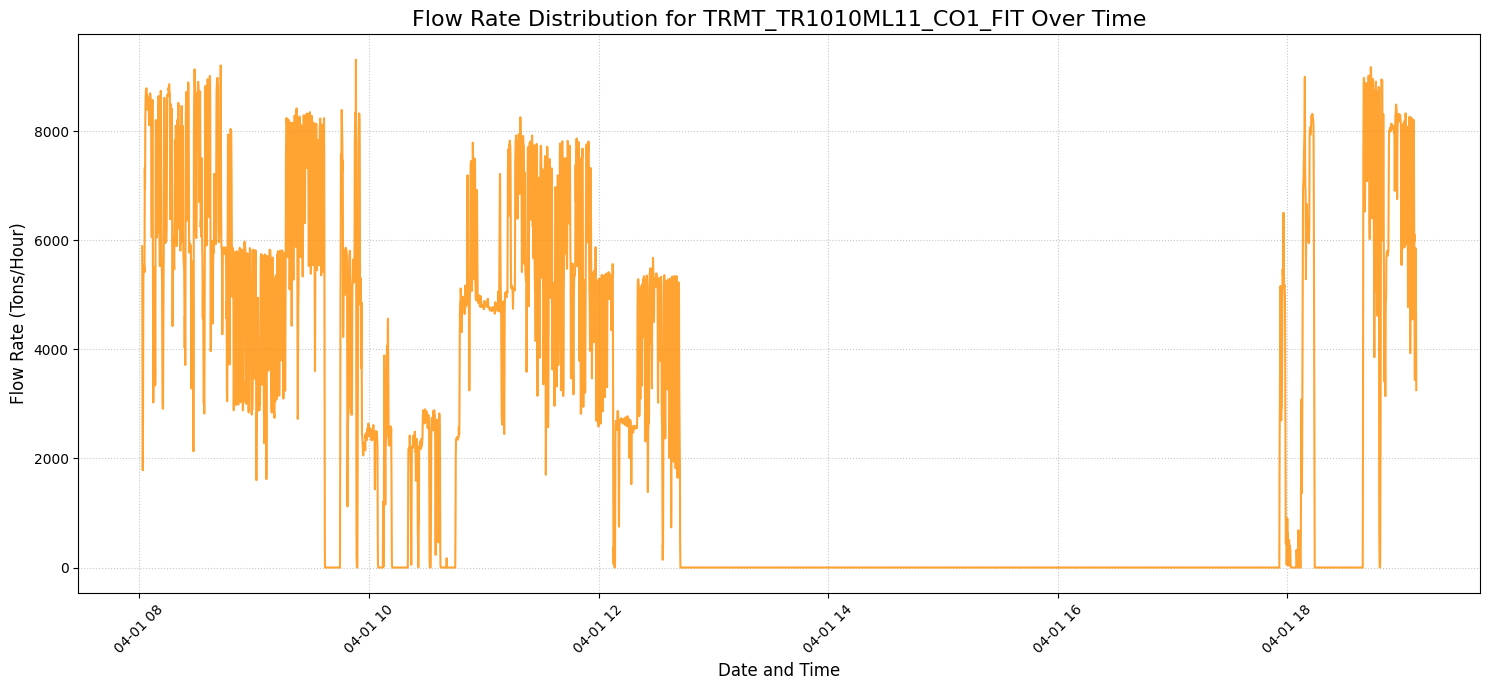

In [39]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_track[df_track['PI_Tag_Extracted'] == 'TRMT_TR1010ML11_CO1_FIT'], x='Time', y='Value', color='darkorange', alpha=0.8)
plt.title('Flow Rate Distribution for TRMT_TR1010ML11_CO1_FIT Over Time', fontsize=16)
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Flow Rate (Tons/Hour)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
display(df_track[['Time', 'PI_Tag_Extracted', 'Value']].head(10))

,Time,PI_Tag_Extracted,Value
25200,2026-04-01 08:01:25.040008,TRMT_DN3020ML12_BF1_FIT,2097.756104
18000,2026-04-01 08:01:26.040008,TRMT_DN3020ML10_BF1_FIT,2647.555908
21600,2026-04-01 08:01:26.040008,TRMT_DN3020ML11_BF1_FIT,204.886002
0,2026-04-01 08:01:26.056000,TRMT_TR1010ML11_CO1_FIT,5892.745117
25201,2026-04-01 08:01:30.040008,TRMT_DN3020ML12_BF1_FIT,843.749023
21601,2026-04-01 08:01:31.040008,TRMT_DN3020ML11_BF1_FIT,116.936996
18001,2026-04-01 08:01:31.040008,TRMT_DN3020ML10_BF1_FIT,2730.229004
1,2026-04-01 08:01:31.056000,TRMT_TR1010ML11_CO1_FIT,5428.761719
25202,2026-04-01 08:01:35.040008,TRMT_DN3020ML12_BF1_FIT,429.157990
21602,2026-04-01 08:01:36.040008,TRMT_DN3020ML11_BF1_FIT,96.295998


In [38]:
df_track['Date_Only'] = df_track['Time'].dt.date
display(df_track[['Date_Only', 'PI_Tag_Extracted', 'Value']].head(10))

,Date_Only,PI_Tag_Extracted,Value
25200,2026-04-01,TRMT_DN3020ML12_BF1_FIT,2097.756104
18000,2026-04-01,TRMT_DN3020ML10_BF1_FIT,2647.555908
21600,2026-04-01,TRMT_DN3020ML11_BF1_FIT,204.886002
0,2026-04-01,TRMT_TR1010ML11_CO1_FIT,5892.745117
25201,2026-04-01,TRMT_DN3020ML12_BF1_FIT,843.749023
21601,2026-04-01,TRMT_DN3020ML11_BF1_FIT,116.936996
18001,2026-04-01,TRMT_DN3020ML10_BF1_FIT,2730.229004
1,2026-04-01,TRMT_TR1010ML11_CO1_FIT,5428.761719
25202,2026-04-01,TRMT_DN3020ML12_BF1_FIT,429.157990
21602,2026-04-01,TRMT_DN3020ML11_BF1_FIT,96.295998


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### Data Time Range Verification

Let's check the actual time range of the processed data to understand why only a limited number of shifts are present in the aggregated results. This will help clarify the '30 days of data' context mentioned earlier.

In [33]:
min_time = df_track['Time'].min()
max_time = df_track['Time'].max()

print(f"Minimum timestamp in df_track: {min_time}")
print(f"Maximum timestamp in df_track: {max_time}")
print(f"Data duration: {max_time - min_time}")

Minimum timestamp in df_track: 2026-04-01 08:01:25.040008
Maximum timestamp in df_track: 2026-04-01 19:08:01.024002
Data duration: 0 days 11:06:35.983994


## Section 2: Shift & Manpower Model

To build the shift and manpower model, I need the roster data. Please provide the file (e.g., CSV or Excel) containing the shift schedule with details like Date, Employee, and Shift Codes (M, N, O, AL, MC). Once provided, I will digitize this schedule and calculate active manpower per shift.

## Section 4: DN Performance Comparison
Based on the aggregations and visualizations, I will compare the performance of DN10, DN11, and DN12 across shifts.

In [41]:
import pandas as pd

# Instead of reading from a file, use the already processed df_track DataFrame
df = df_track.pivot_table(index='Time', columns='PI_Tag_Extracted', values='Value')

# Rename columns to match the names used in the subsequent feature engineering steps
df.rename(columns={
    'TRMT_TR1010ML11_CO1_FIT': 'TR11',
    'TRMT_DN3020ML10_BF1_FIT': 'DN10',
    'TRMT_DN3020ML11_BF1_FIT': 'DN11',
    'TRMT_DN3020ML12_BF1_FIT': 'DN12'
}, inplace=True)

# Resample to 1-minute frequency, taking the mean
df = df.resample('1min').mean()

# Rolling features (stability)
df['TR11_mean_5'] = df['TR11'].rolling(5).mean()
df['TR11_std_5'] = df['TR11'].rolling(5).std()

df['DN10_mean_5'] = df['DN10'].rolling(5).mean()
df['DN11_mean_5'] = df['DN11'].rolling(5).mean()
df['DN12_mean_5'] = df['DN12'].rolling(5).mean()

# Lag features (IMPORTANT for prediction)
for lag in [1,2,3,5,10]:
    df[f'TR11_lag_{lag}'] = df['TR11'].shift(lag)
    df[f'DN11_lag_{lag}'] = df['DN11'].shift(lag)

# Drop NA values introduced by rolling and lag calculations
df = df.dropna()

print("Processed data with rolling and lag features:")
display(df.head())

Processed data with rolling and lag features:


PI_Tag_Extracted,DN10,DN11,DN12,TR11,TR11_mean_5,TR11_std_5,DN10_mean_5,DN11_mean_5,DN12_mean_5,TR11_lag_1,DN11_lag_1,TR11_lag_2,DN11_lag_2,TR11_lag_3,DN11_lag_3,TR11_lag_5,DN11_lag_5,TR11_lag_10,DN11_lag_10
Time,,,,,,,,,,,,,,,,,,,
2026-04-01 08:11:00,2157.925156,3054.362081,1935.432751,6723.057170,6297.634969,1024.722225,2235.010737,2310.813332,2125.665505,7010.518921,3079.290853,7142.243083,3035.457174,5951.041239,2258.937386,7441.784993,2805.344467,3596.849348,106.616572
2026-04-01 08:12:00,1969.937668,2266.095007,2307.537161,4627.558390,6290.883761,1038.220297,2127.131281,2738.828500,2002.866289,6723.057170,3054.362081,7010.518921,3079.290853,7142.243083,3035.457174,4661.314433,126.019168,5757.963949,849.444180
2026-04-01 08:13:00,2715.798258,237.022913,2534.420471,6806.096232,6461.894759,1038.668942,2180.549187,2334.445605,2070.526553,4627.558390,2266.095007,6723.057170,3054.362081,7010.518921,3079.290853,5951.041239,2258.937386,8536.605835,3042.811259
2026-04-01 08:14:00,2157.689301,2975.744324,1601.310398,7577.515218,6548.949186,1124.630549,2283.281028,2322.503035,1975.026068,6806.096232,237.022913,4627.558390,2266.095007,6723.057170,3054.362081,7142.243083,3035.457174,8561.727539,3040.737895
2026-04-01 08:15:00,2808.979187,3048.872904,2880.797709,8735.738548,6893.993112,1502.739168,2362.065914,2316.419446,2251.899698,7577.515218,2975.744324,6806.096232,237.022913,4627.558390,2266.095007,7010.518921,3079.290853,8551.911784,3034.224099


In [34]:
print("### Key Performance Indicators by Shift and DN Line\n")
display(aggregated_performance.sort_values(by=['Shift_Date', 'Shift_ID', 'average_rate'], ascending=False))

### Key Performance Indicators by Shift and DN Line



,Shift_Date,Shift_ID,Shift_Type,PI_Tag_Extracted,average_rate,total_imported_quantity,data_point_count,min_rate,max_rate,std_dev_rate
7,2026-04-01,Shift 3,Day,TRMT_TR1010ML11_CO1_FIT,5105.905292,24960.952040,3511,0.000000,9312.916992,2236.782157
6,2026-04-01,Shift 3,Day,TRMT_DN3020ML12_BF1_FIT,1906.270650,9297.909687,3509,-37.119999,4005.656006,1247.115266
4,2026-04-01,Shift 3,Day,TRMT_DN3020ML10_BF1_FIT,1685.130248,8234.228247,3503,0.000000,3382.611084,1242.792684
5,2026-04-01,Shift 3,Day,TRMT_DN3020ML11_BF1_FIT,1610.518802,8038.070718,3560,0.000000,3143.154053,1204.289948
3,2026-04-01,Shift 1,Night,TRMT_TR1010ML11_CO1_FIT,6583.323100,813.743253,89,3251.787109,8329.339844,1397.645198
1,2026-04-01,Shift 1,Night,TRMT_DN3020ML11_BF1_FIT,2774.928574,154.160116,40,1618.254028,2948.179932,247.082108
2,2026-04-01,Shift 1,Night,TRMT_DN3020ML12_BF1_FIT,2426.202607,306.652988,91,2208.177979,2657.468994,94.927620
0,2026-04-01,Shift 1,Night,TRMT_DN3020ML10_BF1_FIT,2038.105109,274.554267,97,32.001999,3076.226074,1113.164420


## Section 5: Key Insights
Here are the main operational insights derived from the analysis:

1.  **Overall Throughput**: The "Total Imported Quantity per Shift" bar chart reveals the daily and shift-wise contribution of each DN line to the overall import. We can observe periods of high and low activity.
2.  **Variability Between Shifts (Day vs Night)**:
    *   The boxplots show the distribution of rates. We can visually compare if Day shifts are generally more stable or have higher sustained rates compared to Night shifts, or vice-versa. Wide boxes indicate higher variability.
    *   The heatmap provides a concise view of average rates. It helps to quickly spot which shifts and which lines achieve the highest (darker green) average import rates.
3.  **DN Line Performance**: By examining the `average_rate` and `total_imported_quantity` from the aggregated table and the bar charts:
    *   Identify the **highest performing DN line** for each shift. For example, if DN12 consistently shows the highest average rate, it's a primary contributor.
    *   **Variability**: The `std_dev_rate` column indicates the consistency of operation. A high standard deviation means the flow rate is highly variable within that shift for that line, potentially indicating intermittent operation, frequent starts/stops, or fluctuating feed. DN12 has previously shown high variance.
4.  **Underperforming Shifts/Inconsistent Flow**: Periods with significantly lower `total_imported_quantity` or `average_rate` (especially during expected operational hours) pinpoint underperforming shifts. These could be due to equipment downtime, supply chain issues, or operational decisions. The time series plots are crucial for identifying specific downtime periods.
5.  **TRMT_TR1010ML11_CO1_FIT Role**: This tag likely represents an overarching flow or total, which can be compared against the sum of DN10, DN11, and DN12 to potentially perform a mass balance check and identify discrepancies if data for all units were always present simultaneously.


=== SUMMARY STATISTICS ===
PI_Tag_Extracted         DN10         DN11         DN12         TR11
count              298.000000   298.000000   298.000000   298.000000
mean              1673.494994  1608.548153  2002.256286  4819.218669
std               1150.337888  1112.695569   874.858675  2257.989164
min                 36.400333    65.562143     2.888167     0.000000
25%                 55.391197    88.764827  1582.025289  3232.884572
50%               2254.862803  2133.846591  2245.543170  4963.793132
75%               2707.831268  2521.420250  2621.433239  6702.575999
max               3319.481771  3083.314311  3884.932495  8735.738548


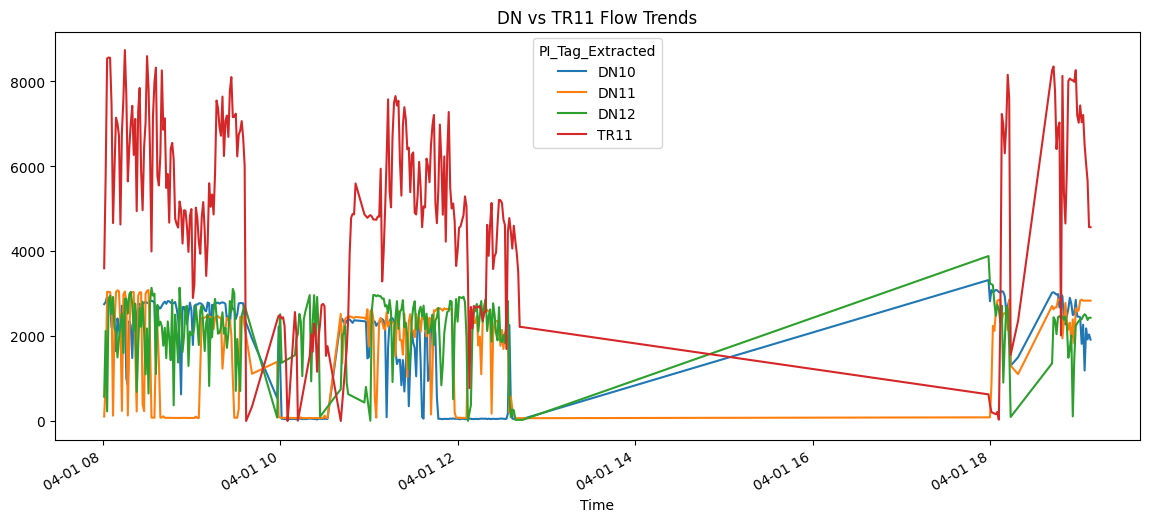


=== CLASSIFICATION REPORT (with SMOTE) ===
              precision    recall  f1-score   support

           0       0.76      0.81      0.78        36
           1       0.63      0.57      0.60        21

    accuracy                           0.72        57
   macro avg       0.70      0.69      0.69        57
weighted avg       0.71      0.72      0.72        57


RMSE: 2495.159424195278

=== FEATURE IMPORTANCE (from SMOTE-trained Classifier) ===
TR11_mean_5    0.089301
DN11_lag_5     0.074513
TR11_lag_1     0.064514
TR11           0.064351
DN10_lag_1     0.056616
TR11_lag_2     0.053147
DN10_mean_5    0.047183
DN10_lag_5     0.043098
TR11_lag_3     0.042582
DN10_lag_3     0.040534
dtype: float64

Downtime %: 1.006711409395973
Utilization %: 91.61073825503355

=== REAL-TIME PREDICTION ===
NORMAL


In [50]:
# ==========================================
# VALE IMPORT PROCESS - FULL PIPELINE
# DN10, DN11, DN12, TR11 ANALYSIS + AI MODEL
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, mean_squared_error
from imblearn.over_sampling import SMOTE # Import SMOTE for class balancing

# ==========================================
# 1. LOAD DATA (USING PREVIOUSLY PROCESSED df_track)
# ==========================================

# Use the df_track DataFrame already prepared in previous steps
# It contains the cleaned and merged data for the target equipment.

# ==========================================
# 2. CLEAN DATA (ALREADY HANDLED IN df_track PREPARATION)
# ==========================================

# The df_track DataFrame is already cleaned, sorted, and has 'PI_Tag_Extracted' as 'Tag'.
# No further cleaning steps are explicitly needed here if df_track is used as the base.

# ==========================================
# 3. FILTER SYSTEM TAGS (ALREADY HANDLED IN df_track PREPARATION)
# ==========================================

# df_track is already filtered for the target tags.

# ==========================================
# 4. PIVOT DATA (TIME SERIES FORMAT)
# ==========================================

df_pivot = df_track.pivot_table(index='Time', columns='PI_Tag_Extracted', values='Value')

# Rename columns to match the general system names used in the subsequent feature engineering steps
df_pivot.rename(columns={
    'TRMT_TR1010ML11_CO1_FIT': 'TR11',
    'TRMT_DN3020ML10_BF1_FIT': 'DN10',
    'TRMT_DN3020ML11_BF1_FIT': 'DN11',
    'TRMT_DN3020ML12_BF1_FIT': 'DN12'
}, inplace=True)

# Resample to 1-minute
df_pivot = df_pivot.resample('1min').mean()

# ==========================================
# 5. DATA CLEANING (INDUSTRIAL)
# ==========================================

# Remove negative values
df_pivot[df_pivot < 0] = np.nan

# Fill small gaps
df_pivot = df_pivot.interpolate(limit=5)

# Drop remaining NA
df_pivot = df_pivot.dropna()

# ==========================================
# 6. EDA SUMMARY
# ==========================================

print("\n=== SUMMARY STATISTICS ===")
print(df_pivot.describe())

# Plot trends
df_pivot.plot(figsize=(14,6), title="DN vs TR11 Flow Trends")
plt.show()

# ==========================================
# 7. FEATURE ENGINEERING
# ==========================================

df_feat = df_pivot.copy()

# Rolling mean & std
for col in df_feat.columns:
    df_feat[f'{col}_mean_5'] = df_feat[col].rolling(5).mean()
    df_feat[f'{col}_std_5'] = df_feat[col].rolling(5).std()

# Lag features
lags = [1,2,3,5,10]
for lag in lags:
    for col in ['TR11', 'DN10', 'DN11', 'DN12']:
        df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)

df_feat = df_feat.dropna()

# ==========================================
# 8. TARGET CREATION
# ==========================================

# Future TR11
df_feat['TR11_future'] = df_feat['TR11'].shift(-5)

# Drop detection (threshold adjustable)
df_feat['Drop_Event'] = (df_feat['TR11_future'] < 4000).astype(int)

df_feat = df_feat.dropna()

# ==========================================
# 9. TRAIN MODEL (CLASSIFICATION)
# ==========================================

features = [col for col in df_feat.columns if col not in ['Drop_Event', 'TR11_future']]

X = df_feat[features]
y = df_feat['Drop_Event']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

model_clf = RandomForestClassifier(n_estimators=100, random_state=42) # Added random_state for reproducibility
model_clf.fit(X_train_resampled, y_train_resampled)

# Evaluate
y_pred = model_clf.predict(X_test)
print("\n=== CLASSIFICATION REPORT (with SMOTE) ===")
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(model_clf, "tr11_model.pkl")

# ==========================================
# 10. REGRESSION MODEL (FLOW PREDICTION)
# ==========================================

y_reg = df_feat['TR11_future']

model_reg = GradientBoostingRegressor(random_state=42) # Added random_state for reproducibility
model_reg.fit(X_train, y_reg.loc[X_train.index])

pred_reg = model_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg.loc[X_test.index], pred_reg))
print("\nRMSE:", rmse)

# ==========================================
# 11. FEATURE IMPORTANCE
# ==========================================

importances = pd.Series(model_clf.feature_importances_, index=features)
print("\n=== FEATURE IMPORTANCE (from SMOTE-trained Classifier) ===")
print(importances.sort_values(ascending=False).head(10))

# ==========================================
# 12. KPI CALCULATION
# ==========================================

df_kpi = df_pivot.copy()

df_kpi['Downtime'] = (df_kpi['TR11'] < 1).astype(int)
df_kpi['Utilization'] = (df_kpi['TR11'] > 1000).astype(int)

print("\nDowntime %:", df_kpi['Downtime'].mean()*100)
print("Utilization %:", df_kpi['Utilization'].mean()*100)

# ==========================================
# 13. EXPORT FOR POWER BI
# ==========================================

df_feat['Drop_Risk'] = model_clf.predict(X) # Predict on original X, not resampled

df_feat.to_csv("processed_pi_data.csv")

# ==========================================
# 14. REAL-TIME PREDICTION (SIMULATION)
# ==========================================

latest = df_feat.tail(1)

prediction = model_clf.predict(latest[features])[0]

print("\n=== REAL-TIME PREDICTION ===")
if prediction == 1:
    print("⚠ TR11 DROP RISK")
else:
    print("NORMAL")

# ==========================================
# END
# ==========================================
